# Lab 3 — Filtering & Edge Detection

In [1]:
import os 
import cv2 
import numpy as np 
import matplotlib.pyplot as plt 
 
os.makedirs("./outputs", exist_ok=True) 
 
%matplotlib inline

In [2]:
def show_image(img, title="Image", cmap=None, figsize=(6, 6)): 
    plt.figure(figsize=figsize) 
 
    plt.subplot(2, 1, 1) 
    if img.ndim == 2: 
        plt.imshow(img, cmap=cmap) 
    else: 
        plt.imshow(img) 
    plt.title(title) 
    plt.axis("off") 
 
    plt.subplot(2, 1, 2) 
    if img.ndim == 2: 
        plt.hist(img.ravel(), bins=256, range=[0, 256]) 
        plt.title("Histogram") 
        plt.xlabel("Intensity value") 
        plt.ylabel("Number of pixels") 
    else: 
        plt.hist(img[:, :, 0].ravel(), bins=256, range=[0, 256], 
alpha=0.5, label="Red") 
        plt.hist(img[:, :, 1].ravel(), bins=256, range=[0, 256], 
alpha=0.5, label="Green") 
        plt.hist(img[:, :, 2].ravel(), bins=256, range=[0, 256], 
alpha=0.5, label="Blue") 
        plt.title("Color channel histograms") 
        plt.xlabel("Intensity value") 
        plt.ylabel("Number of pixels") 
        plt.legend() 
 
    plt.tight_layout() 
    plt.show()

In [3]:
def show_images(images, titles, cmap=None, figsize=(15, 7)): 
    n = len(images) 
    plt.figure(figsize=figsize) 
 
    for i, (img, title) in enumerate(zip(images, titles), start=1): 
        plt.subplot(2, n, i) 
        if img.ndim == 2: 
            plt.imshow(img, cmap=cmap) 
        else: 
            plt.imshow(img) 
        plt.title(title) 
        plt.axis("off") 
 
        plt.subplot(2, n, n + i) 
        if img.ndim == 2: 
            plt.hist(img.ravel(), bins=256, range=[0, 256]) 
            plt.title("Histogram") 
            plt.xlabel("Intensity") 
            plt.ylabel("Count") 
        else: 
            plt.hist(img[:, :, 0].ravel(), bins=256, range=[0, 256], 
alpha=0.5, label="R") 
            plt.hist(img[:, :, 1].ravel(), bins=256, range=[0, 256], 
alpha=0.5, label="G") 
            plt.hist(img[:, :, 2].ravel(), bins=256, range=[0, 256], 
alpha=0.5, label="B") 
            plt.title("Channel histograms") 
            plt.xlabel("Intensity") 
            plt.ylabel("Count") 
            plt.legend() 
 
    plt.tight_layout() 
    plt.show()

## 1.2 Load the images

Lenna shape: (512, 512, 3)
Baboon shape: (512, 512, 3)
Barbara shape: (512, 512)


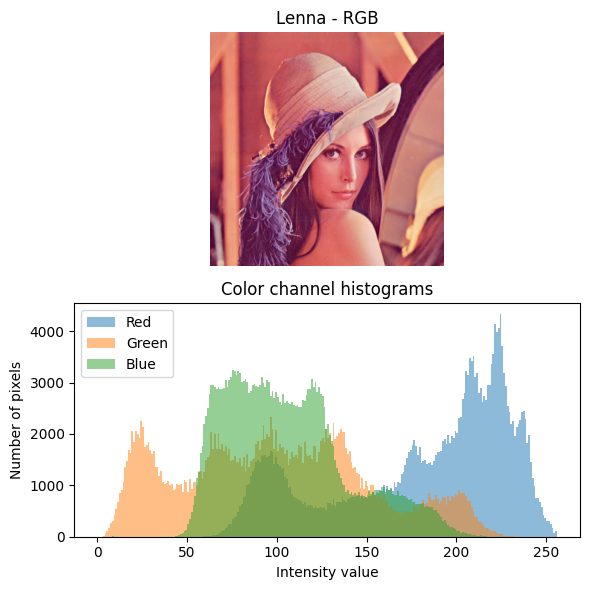

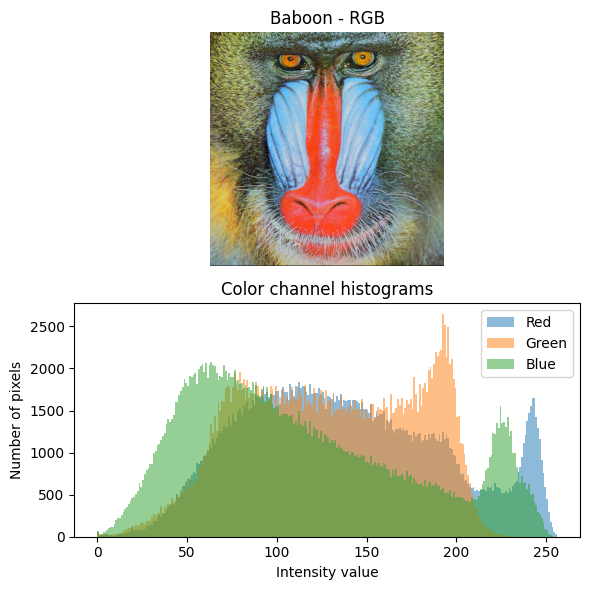

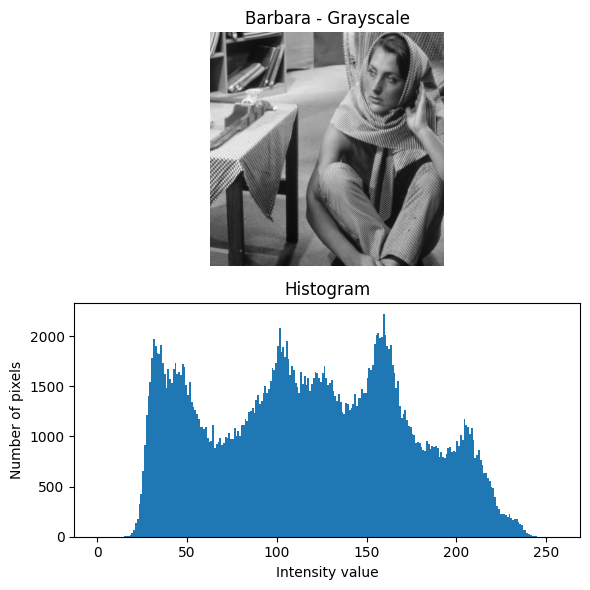

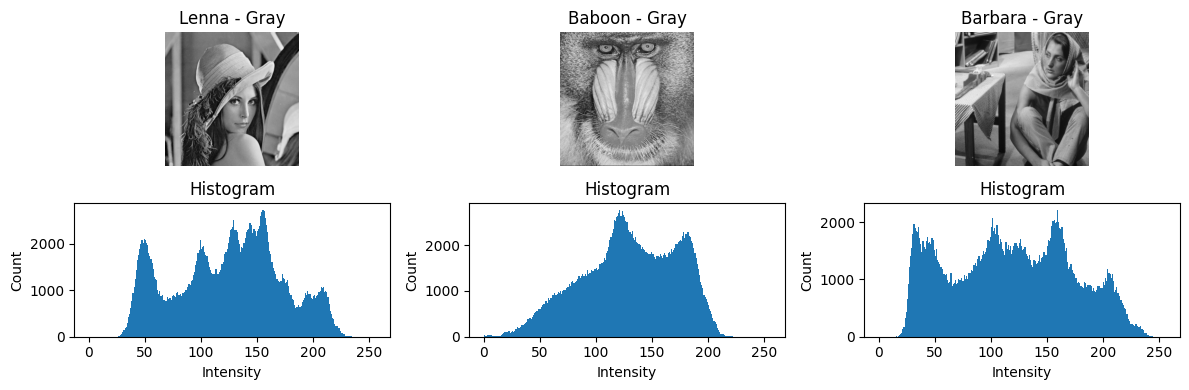

In [4]:
# Let us load the course images first.
lenna_bgr = cv2.imread(".././data/lenna.png") 
baboon_bgr = cv2.imread(".././data/baboon.png") 
barbara_gray = cv2.imread(".././data/barbara.png", cv2.IMREAD_GRAYSCALE) 
 
print("Lenna shape:", lenna_bgr.shape) 
print("Baboon shape:", baboon_bgr.shape) 
print("Barbara shape:", barbara_gray.shape) 

#Convert the color images to RGB for visualization.
lenna_rgb = cv2.cvtColor(lenna_bgr, cv2.COLOR_BGR2RGB) 
baboon_rgb = cv2.cvtColor(baboon_bgr, cv2.COLOR_BGR2RGB) 
 
show_image(lenna_rgb, "Lenna - RGB") 
show_image(baboon_rgb, "Baboon - RGB") 
show_image(barbara_gray, "Barbara - Grayscale", cmap="gray") 

#Now create grayscale versions when needed.
lenna_gray = cv2.cvtColor(lenna_bgr, cv2.COLOR_BGR2GRAY) 
baboon_gray = cv2.cvtColor(baboon_bgr, cv2.COLOR_BGR2GRAY) 
 
show_images( 
    [lenna_gray, baboon_gray, barbara_gray], 
    ["Lenna - Gray", "Baboon - Gray", "Barbara - Gray"], 
    cmap="gray", 
    figsize=(12, 4) 
) 

## 1.3 Understand convolution-based filtering

In [5]:
# A simple averaging filter might look like this:
avg_kernel = np.array([ 
    [1/9, 1/9, 1/9], 
    [1/9, 1/9, 1/9], 
    [1/9, 1/9, 1/9] 
], dtype=np.float32)

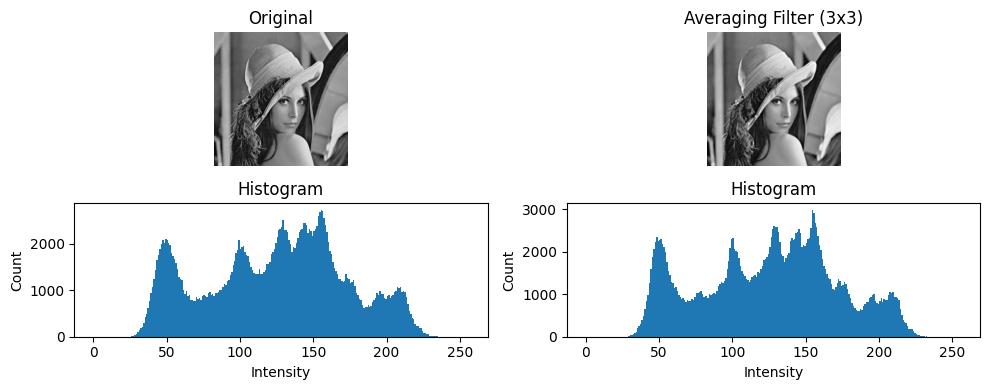

In [6]:
lenna_blur_avg = cv2.filter2D(lenna_gray, -1, avg_kernel) 
 
show_images( 
    [lenna_gray, lenna_blur_avg], 
    ["Original", "Averaging Filter (3x3)"], 
    cmap="gray", 
    figsize=(10, 4) 
)

## Task 2 — Group work: Smoothing, noise removal, and custom linear filters

### 2.1 Add noise and smooth with a Gaussian filter

In [7]:
def add_gaussian_noise(img, sigma=20): 
    noise = np.random.normal(0, sigma, img.shape) 
    noisy = img.astype(np.float32) + noise 
    noisy = np.clip(noisy, 0, 255) 
    return noisy.astype(np.uint8)

In [ ]:
# Apply it to one grayscale image first.
lenna_noisy = add_gaussian_noise(lenna_gray, sigma=20) 
show_images( 
    [lenna_gray, lenna_noisy], 
    ["Original", "Noisy (sigma=20)"], 
    cmap="gray", 
    figsize=(10, 4) 
) 

# Apply Gaussian filtering
# Use OpenCV's built-in Gaussian filter.
# Note 3, 3 and 7, 7 are the kernal dimentions 
lenna_gauss_3 = cv2.GaussianBlur(lenna_noisy, (3, 3), 0) 
lenna_gauss_7 = cv2.GaussianBlur(lenna_noisy, (7, 7), 0) 
 
show_images( 
    [lenna_noisy, lenna_gauss_3, lenna_gauss_7], 
    ["Noisy", "Gaussian 3x3", "Gaussian 7x7"], 
    cmap="gray", 
    figsize=(15, 4) 
) 

# Save the outputs
cv2.imwrite("./outputs/lenna_noisy.png", lenna_noisy) 
cv2.imwrite("./outputs/lenna_gaussian_3x3.png", lenna_gauss_3) 
cv2.imwrite("./outputs/lenna_gaussian_7x7.png", lenna_gauss_7)

## Discussion prompt
- Which filtered image looks cleaner?  
The Gaussian smoothed image looks cleaner because it reduces noise.
- Which filtered image loses more detail?  
The blurred (Gaussian) image loses more fine details like edges and textures.
- Is there a trade-off between noise removal and sharpness?  
Yes. When noise is reduced, the image becomes smoother but also less sharp.
- How does the histogram of the noisy image differ from the histogram after Gaussian
smoothing?  
Noisy image histogram: more scattered and irregular due to random pixel values.  
Smoothed image histogram: more compact and smooth because pixel values become more similar.

### 2.2 Build some simple custom linear filters

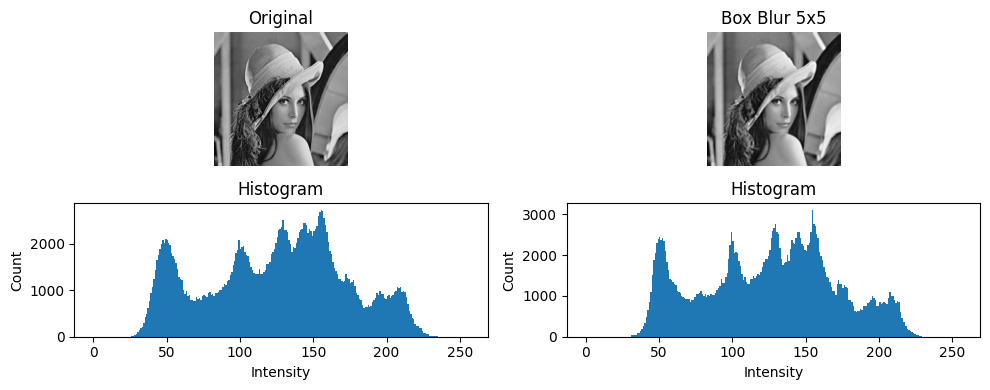

In [8]:
box5 = np.ones((5, 5), dtype=np.float32) / 25.0 
lenna_box5 = cv2.filter2D(lenna_gray, -1, box5) 
show_images( 
    [lenna_gray, lenna_box5], 
    ["Original", "Box Blur 5x5"], 
    cmap="gray", 
    figsize=(10, 4) 
)

### A sharpening kernel

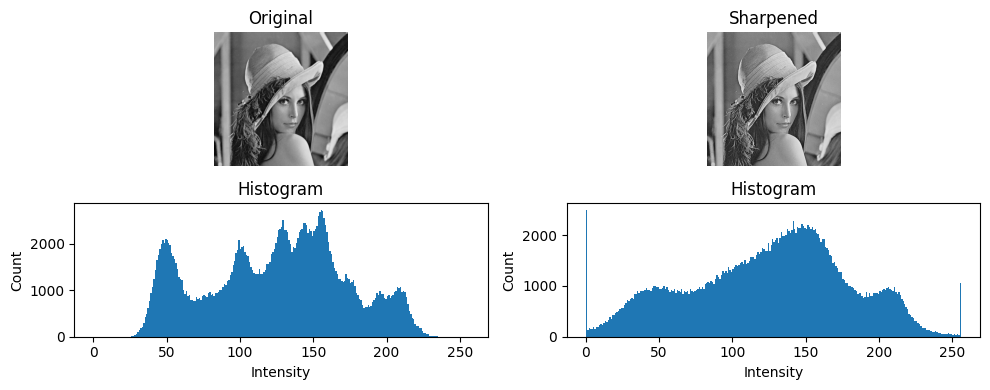

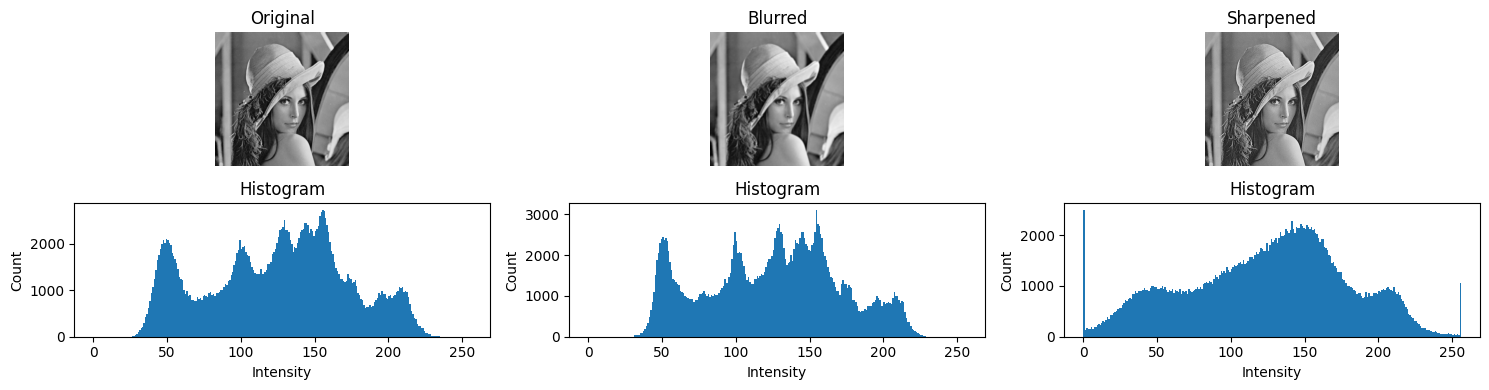

In [9]:
sharp_kernel = np.array([ 
    [ 0, -1,  0], 
    [-1,  5, -1], 
    [ 0, -1,  0] 
], dtype=np.float32) 
 
lenna_sharp = cv2.filter2D(lenna_gray, -1, sharp_kernel) 
show_images( 
    [lenna_gray, lenna_sharp], 
    ["Original", "Sharpened"], 
    cmap="gray", 
    figsize=(10, 4) 
) 

# Compare smoothing and sharpening
show_images( 
    [lenna_gray, lenna_box5, lenna_sharp], 
    ["Original", "Blurred", "Sharpened"], 
    cmap="gray", 
    figsize=(15, 4) 
)

### Discussion prompt
- What kind of image details become weaker after blur?  
Edges and fine details become weaker or less clear.
- What kind of image details become stronger after sharpening?  
Edges and fine details become stronger and more visible.
- Does sharpening also make noise more visible sometimes?  
Yes. It can increase noise and make it easier to see.
- What happens to the histogram after blur?  
It becomes more smooth and narrow, with pixel values closer together.
- What happens to the histogram after sharpening?  
It becomes more spread out, with more extreme (high and low) values.

## Task 3 — Group work: Sobel and Canny edge detection

### 3.1 Detect edges using Sobel filters

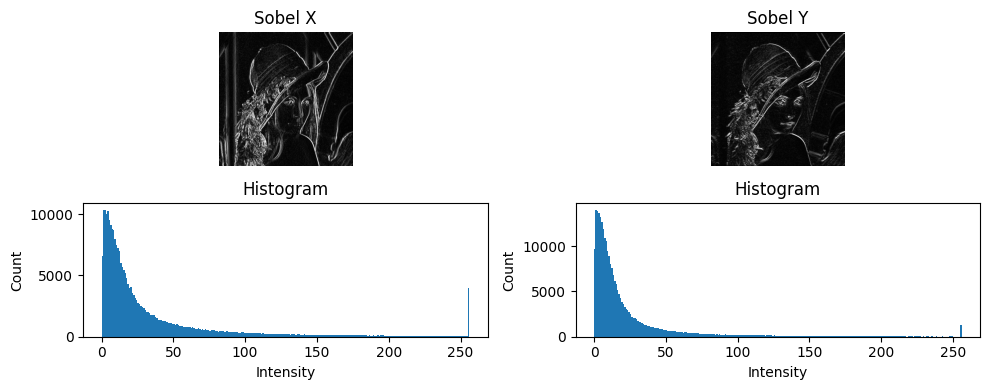

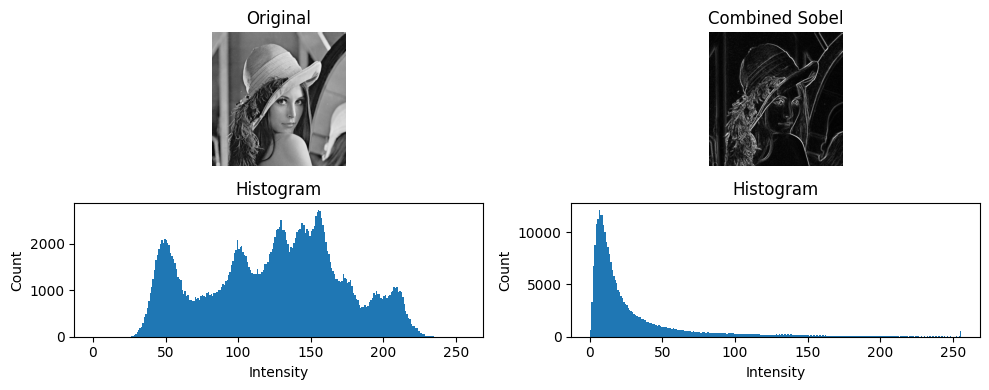

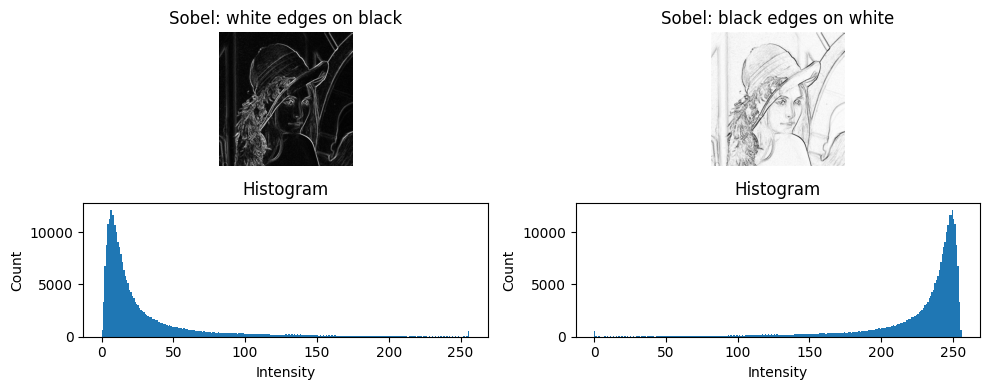

True

In [10]:
# Compute Sobel responses in x and y
# try to search online why we used 64 representation here 
sobel_x = cv2.Sobel(lenna_gray, cv2.CV_64F, 1, 0, ksize=3) 
sobel_y = cv2.Sobel(lenna_gray, cv2.CV_64F, 0, 1, ksize=3) 
 
sobel_x_abs = cv2.convertScaleAbs(sobel_x) 
sobel_y_abs = cv2.convertScaleAbs(sobel_y) 
 
show_images( 
    [sobel_x_abs, sobel_y_abs], 
    ["Sobel X", "Sobel Y"], 
    cmap="gray", 
    figsize=(10, 4) 
) 

# Combine the two directions
# A simple way is to combine them with equal weights.
sobel_combined = cv2.addWeighted(sobel_x_abs, 0.5, sobel_y_abs, 0.5, 0) 
show_images( 
    [lenna_gray, sobel_combined], 
    ["Original", "Combined Sobel"], 
    cmap="gray", 
    figsize=(10, 4) 
) 

# This is simply the inverted version of the edge image.
sobel_inverted = 255 - sobel_combined 
 
show_images( 
    [sobel_combined, sobel_inverted], 
    ["Sobel: white edges on black", "Sobel: black edges on white"], 
    cmap="gray", 
    figsize=(10, 4) 
) 

# Save results
cv2.imwrite("./outputs/lenna_sobel_x.png", sobel_x_abs) 
cv2.imwrite("./outputs/lenna_sobel_y.png", sobel_y_abs) 
cv2.imwrite("./outputs/lenna_sobel_combined.png", sobel_combined) 
cv2.imwrite("./outputs/lenna_sobel_inverted.png", sobel_inverted)

### Discussion prompt
- Which structures are emphasized by Sobel?  
Sobel highlights edges, especially areas with strong intensity change like object borders, lines, and shapes.
- Do you see a difference between Sobel X and Sobel Y?  
Yes:  
Sobel X detects vertical edges (changes left ↔ right)  
Sobel Y detects horizontal edges (changes up ↕ down)
- Does the inverted display change the result itself, or only the visualization?  
It only changes the visual appearance. The edge values stay the same, but colors are flipped for display.
- How does the histogram of an edge image differ from the histogram of the original
grayscale image?  
Grayscale image histogram: wide spread of many intensity values.  
Edge image histogram: mostly low values (dark background) and a few high values (strong edges).

## 3.2 Understand and apply the Canny pipeline

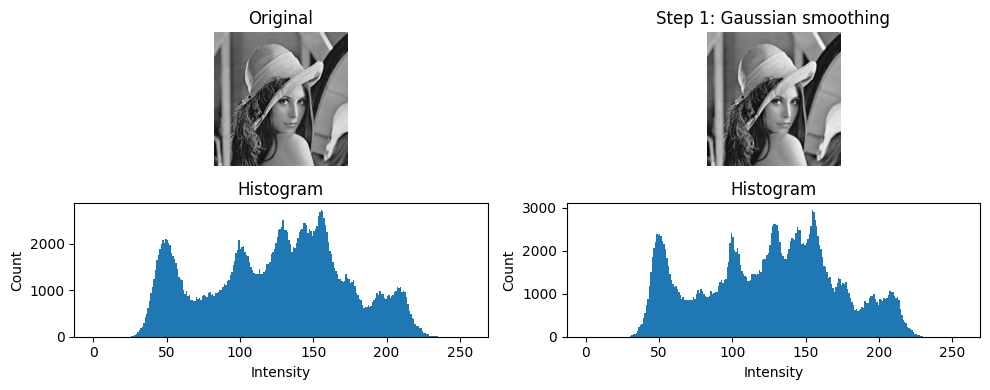

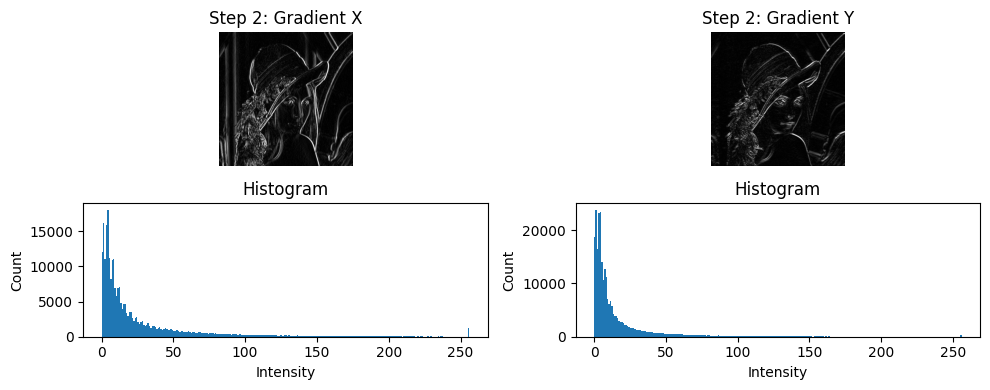

In [11]:
# Step 1: smooth the image
canny_blur = cv2.GaussianBlur(lenna_gray, (5, 5), 1) 
show_images( 
    [lenna_gray, canny_blur], 
    ["Original", "Step 1: Gaussian smoothing"], 
    cmap="gray", 
    figsize=(10, 4) 
) 

#Step 2: compute gradients in x and y
grad_x = cv2.Sobel(canny_blur, cv2.CV_64F, 1, 0, ksize=3) 
grad_y = cv2.Sobel(canny_blur, cv2.CV_64F, 0, 1, ksize=3) 
 
grad_x_abs = cv2.convertScaleAbs(grad_x) 
grad_y_abs = cv2.convertScaleAbs(grad_y) 
 
show_images( 
    [grad_x_abs, grad_y_abs], 
    ["Step 2: Gradient X", "Step 2: Gradient Y"], 
    cmap="gray", 
    figsize=(10, 4) 
)

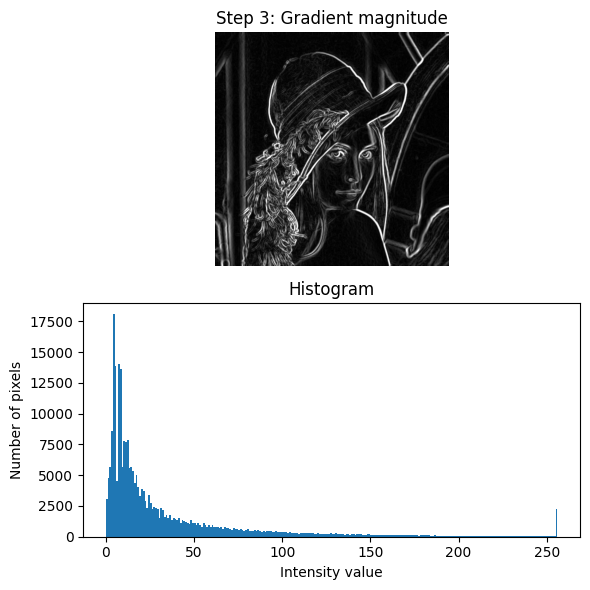

Gradient direction shape: (512, 512)


In [12]:
# Step 3: compute gradient magnitude and direction
grad_magnitude = np.sqrt(grad_x**2 + grad_y**2) 
grad_magnitude = np.clip(grad_magnitude, 0, 255).astype(np.uint8) 
 
grad_direction = np.arctan2(grad_y, grad_x) 
 
show_image(grad_magnitude, "Step 3: Gradient magnitude", cmap="gray") 
print("Gradient direction shape:", grad_direction.shape)

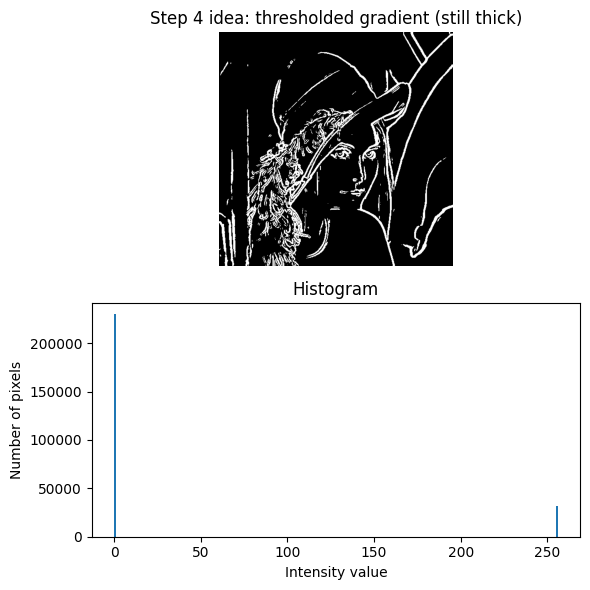

In [13]:
# Step 4: a simple look at edge thinning
# Assuming threshold is 80 (somewhat low) 
thick_edges = (grad_magnitude > 80).astype(np.uint8) * 255 
show_image(thick_edges, "Step 4 idea: thresholded gradient (still thick)", cmap="gray")

### Step 5: double thresholding and hysteresis

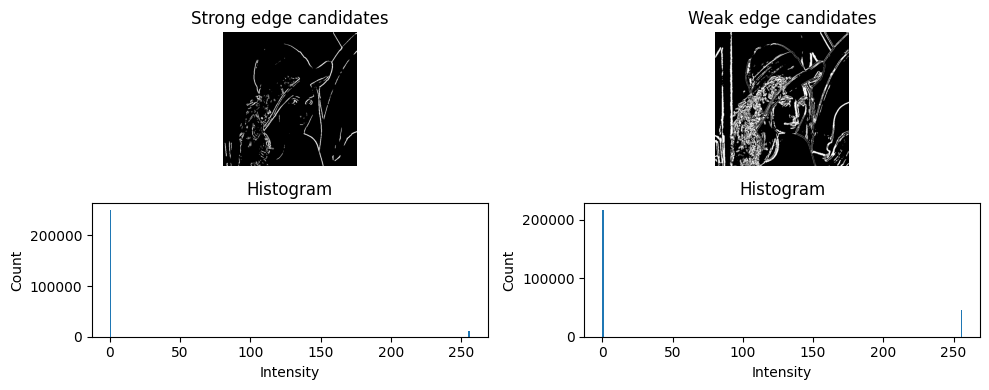

In [14]:
low_thresh = 50 
high_thresh = 150 
 
strong = (grad_magnitude >= high_thresh).astype(np.uint8) * 255 
weak = ((grad_magnitude >= low_thresh) & (grad_magnitude < 
high_thresh)).astype(np.uint8) * 255 
 
show_images( 
    [strong, weak], 
    ["Strong edge candidates", "Weak edge candidates"], 
    cmap="gray", 
    figsize=(10, 4) 
)

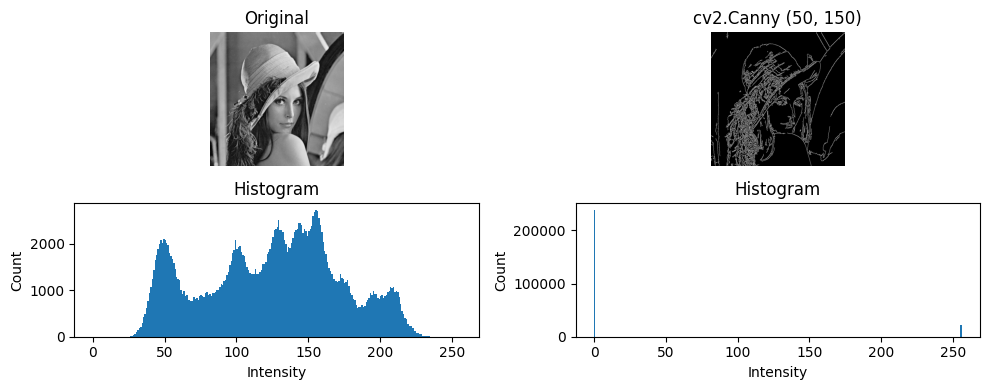

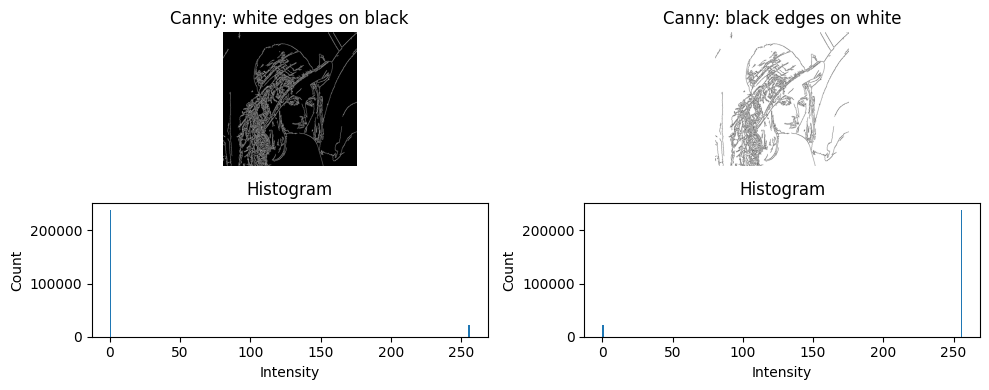

In [15]:
# Final result with OpenCV Canny
canny_50_150 = cv2.Canny(lenna_gray, 50, 150) 
show_images( 
    [lenna_gray, canny_50_150], 
    ["Original", "cv2.Canny (50, 150)"], 
    cmap="gray", 
    figsize=(10, 4) 
)

# Show the Canny result with white background and black edges
canny_inverted = 255 - canny_50_150 
show_images( 
    [canny_50_150, canny_inverted], 
    ["Canny: white edges on black", "Canny: black edges on white"], 
    cmap="gray", 
    figsize=(10, 4) 
) 

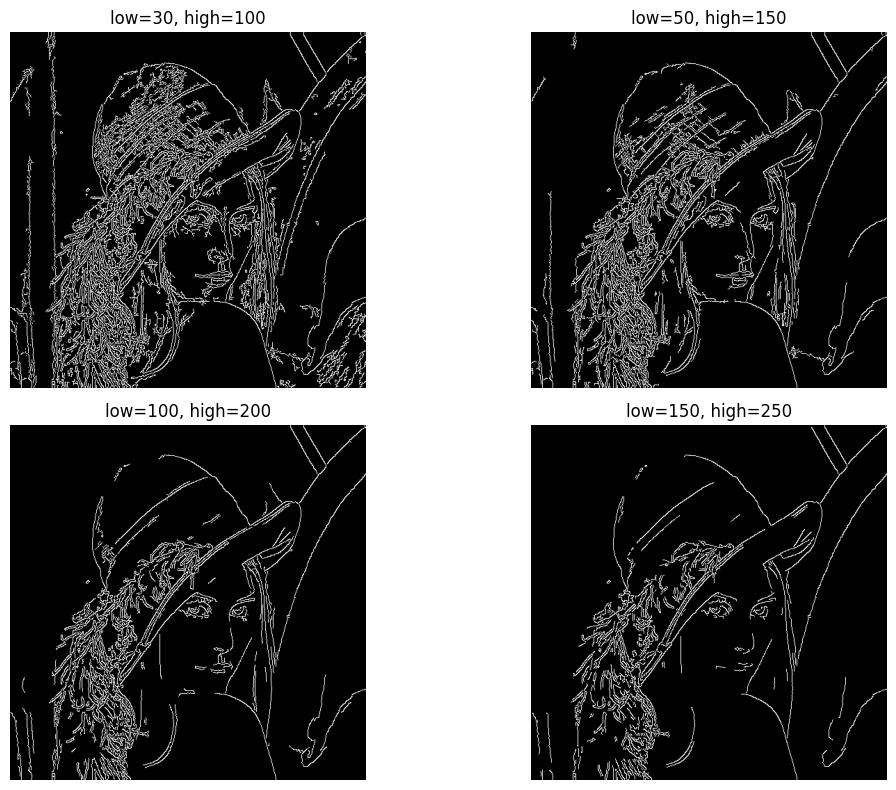

In [16]:
# 3.3 Compare different threshold settings in Canny
threshold_pairs = [ 
    (30, 100), 
    (50, 150), 
    (100, 200), 
    (150, 250) 
] 
 
plt.figure(figsize=(12, 8)) 
for i, (low, high) in enumerate(threshold_pairs, start=1): 
    edges = cv2.Canny(lenna_gray, low, high) 
    plt.subplot(2, 2, i) 
    plt.imshow(edges, cmap="gray") 
    plt.title(f"low={low}, high={high}") 
    plt.axis("off") 
plt.tight_layout() 
plt.show()

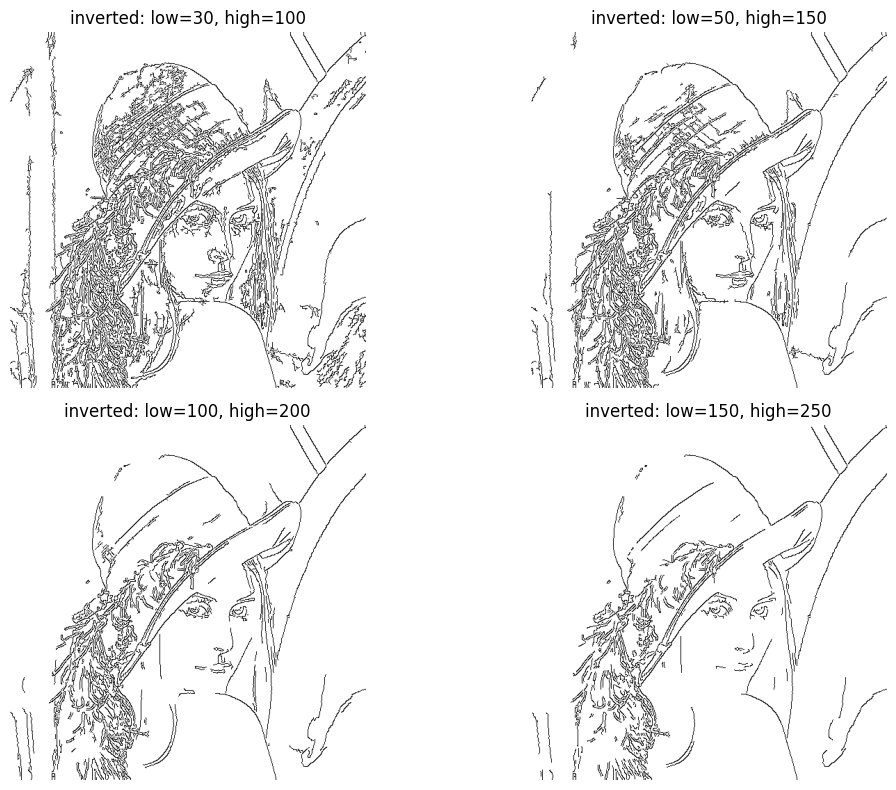

In [17]:
# You can also show the same results in inverted form.
plt.figure(figsize=(12, 8)) 
for i, (low, high) in enumerate(threshold_pairs, start=1): 
    edges = cv2.Canny(lenna_gray, low, high) 
    edges_inv = 255 - edges 
    plt.subplot(2, 2, i) 
    plt.imshow(edges_inv, cmap="gray") 
    plt.title(f"inverted: low={low}, high={high}") 
    plt.axis("off") 
plt.tight_layout() 
plt.show()

### Discussion prompt
- What happens when thresholds are lower?  
 More edges appear (even weak ones), but also more noise (unwanted edges).
- What happens when thresholds are higher?  
Fewer edges appear, mostly strong ones, but you may lose some important details.
- Which setting keeps important edges while removing more unwanted weak edges?  
A middle threshold is best → keeps important edges and removes most weak/noisy edges.
- How do the histograms differ across the different Canny results?  
Low thresholds → histogram has more values (many weak edges).  
High thresholds → histogram has fewer values (only strong edges).  
Middle thresholds → balanced distribution (clear edges, less noise).
